In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
    )
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from gensim import downloader as api
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
warnings.filterwarnings('ignore')


### Preprocessing

In [12]:
# ============================================================
# STEP 1: LOAD TRAIN & TEST DATA
# ============================================================
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (82357, 6)
Test shape:  (20590, 6)


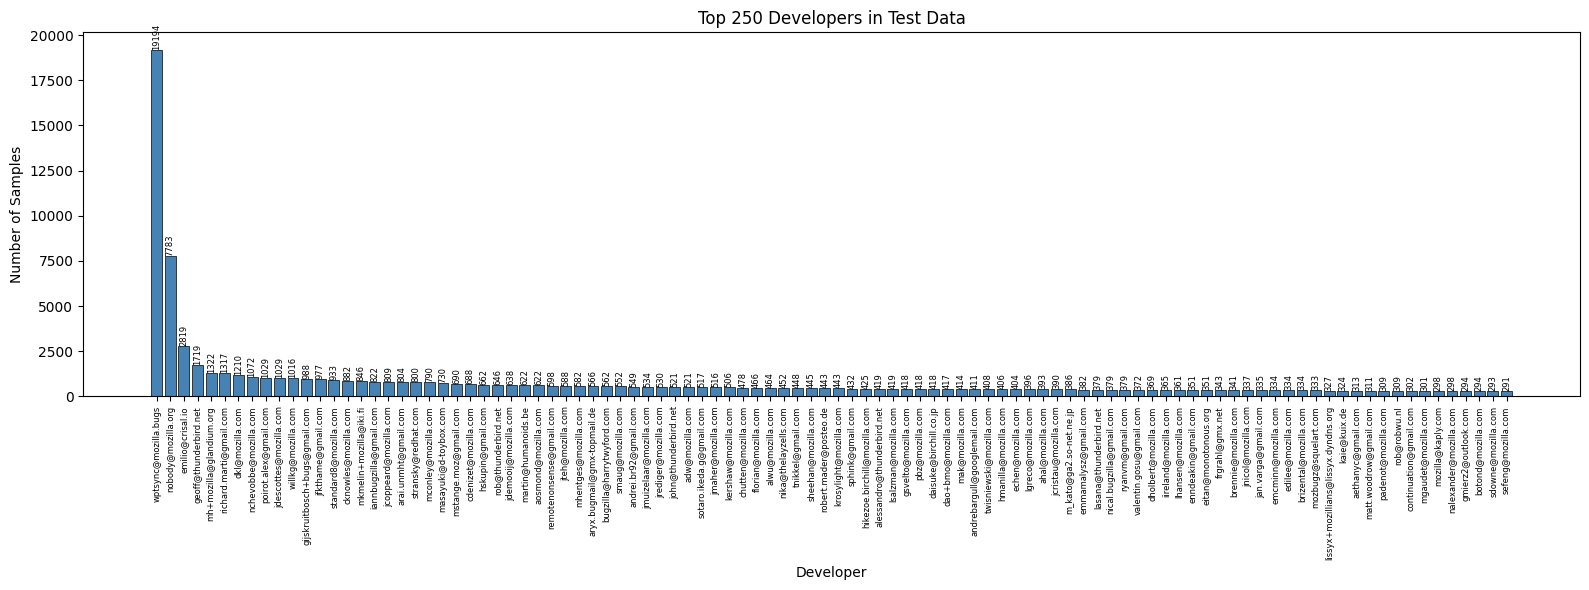

In [13]:
# ============================================================
# TEST SET DEVELOPER DISTRIBUTION (TOP 250)
# ============================================================
dev_counts = df_train["assigned_to"].value_counts().head(100)

dev_counts_df = dev_counts.reset_index()
dev_counts_df.columns = ["developer", "count"]
dev_counts_df

plt.figure(figsize=(16, 6))
bars = plt.bar(dev_counts.index, dev_counts.values, color="steelblue", edgecolor="black", linewidth=0.5)
plt.title("Top 250 Developers in Test Data")
plt.xlabel("Developer")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90, fontsize=6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=6,
        rotation=90,
    )

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# STEP 2: DEFINE FEATURES & TARGET
# ============================================================
X_train_raw = df_train['text'].astype(str).tolist()
X_test_raw  = df_test['text'].astype(str).tolist()

y_train_raw = df_train['assigned_to'].tolist()
y_test_raw  = df_test['assigned_to'].tolist()

In [15]:
# ============================================================
# STEP 3: TEXT PREPROCESSING
# ============================================================
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(texts):
    cleaned = []
    for text in texts:
        text = text.lower()                                 # lowercase
        text = re.sub(r'http\S+|www\S+', '', text)         # remove URLs
        text = re.sub(r'[^a-zA-Z.\-\s]', '', text)         # keep letters, dot, hyphen, space
        text = re.sub(r'\s+', ' ', text).strip()           # remove extra spaces
        words = []
        for w in re.split(r'[\s.-]+', text):
            if not w:
                continue
            if len(w) > 15:
                continue
            if w in stop_words:
                continue
            words.append(lemmatizer.lemmatize(w))
        cleaned.append(' '.join(words))
    return cleaned

X_train_clean = preprocess_text(X_train_raw)
X_test_clean  = preprocess_text(X_test_raw)

print(f"\nSample cleaned text: {X_train_clean[0]}")


Sample cleaned text: requirement defined front fail fast insufficient package installed


In [16]:
# ============================================================
# STEP 3B: FILTER SHORT SAMPLES (< 5 WORDS)
# ============================================================
def filter_by_min_words(texts, labels, min_words=5):
    filtered_texts = []
    filtered_labels = []
    for text, label in zip(texts, labels):
        if len(text.split()) >= min_words:
            filtered_texts.append(text)
            filtered_labels.append(label)
    return filtered_texts, filtered_labels

X_train_clean, y_train_raw = filter_by_min_words(X_train_clean, y_train_raw, min_words=5)
X_test_clean, y_test_raw = filter_by_min_words(X_test_clean, y_test_raw, min_words=5)

print(f"Filtered train size: {len(X_train_clean)}")
print(f"Filtered test size:  {len(X_test_clean)}")

Filtered train size: 79410
Filtered test size:  19827


In [17]:
# ============================================================
# STEP 3C: KEEP TOP-K WORDS BY TF-IDF SCORE
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

TOP_K_TFIDF = 50

def select_top_k_tfidf(texts, vectorizer, top_k):
    tfidf = vectorizer.transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    top_texts = []
    for row_idx in range(tfidf.shape[0]):
        row = tfidf.getrow(row_idx)
        if row.nnz == 0:
            top_texts.append(texts[row_idx])
            continue
        data = row.data
        indices = row.indices
        if row.nnz > top_k:
            top_idx = data.argsort()[-top_k:]
            top_terms = {feature_names[indices[i]] for i in top_idx}
        else:
            top_terms = {feature_names[i] for i in indices}
        tokens = texts[row_idx].split()
        filtered = [t for t in tokens if t in top_terms]
        top_texts.append(" ".join(filtered) if filtered else texts[row_idx])
    return top_texts

tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", lowercase=False)
tfidf_vectorizer.fit(X_train_clean)

X_train_clean = select_top_k_tfidf(X_train_clean, tfidf_vectorizer, TOP_K_TFIDF)
X_test_clean = select_top_k_tfidf(X_test_clean, tfidf_vectorizer, TOP_K_TFIDF)

print(f"TF-IDF top-{TOP_K_TFIDF} sample: {X_train_clean[0]}")

TF-IDF top-50 sample: requirement defined front fail fast insufficient package installed


In [18]:
# ============================================================
# STEP 4: LABEL ENCODING
# ============================================================
label_encoder = LabelEncoder()
label_encoder.fit(y_train_raw)

y_train = label_encoder.transform(y_train_raw)
y_test  = label_encoder.transform(y_test_raw)


num_classes = len(label_encoder.classes_)
print(f"\nNumber of classes (developers): {num_classes}")

# One-hot encode for categorical crossentropy
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  num_classes)


Number of classes (developers): 100


### Embedding

In [19]:
MAX_WORDS = 50
VEC_DIM = 100

def tokenize_texts(texts, max_words):
    tokenized = []
    for text in texts:
        tokens = text.split()
        tokenized.append(tokens[:max_words])
    return tokenized

X_train_tokens = tokenize_texts(X_train_clean, MAX_WORDS)
X_test_tokens  = tokenize_texts(X_test_clean,  MAX_WORDS)


In [20]:
from gensim.models import FastText

print("\nTraining FastText model...")
ft_model = FastText(
    sentences=X_train_tokens,   # list of token lists
    vector_size=VEC_DIM,         # match vec_dim
    window=5,
    min_count=1,
    sg=1,
    workers=4,
    epochs=15
)

def get_ft_embeddings(tokenized, ft_model, max_words, vec_dim):
    embeddings = np.zeros((len(tokenized), max_words, vec_dim), dtype=np.float32)
    for i, tokens in enumerate(tokenized):
        for j, token in enumerate(tokens[:max_words]):
            embeddings[i, j, :] = ft_model.wv[token]
    return embeddings

print("\nGenerating FastText embeddings for TRAIN set...")
X_train_input = get_ft_embeddings(X_train_tokens, ft_model, MAX_WORDS, VEC_DIM)

print("\nGenerating FastText embeddings for TEST set...")
X_test_input = get_ft_embeddings(X_test_tokens, ft_model, MAX_WORDS, VEC_DIM)


Training FastText model...

Generating FastText embeddings for TRAIN set...

Generating FastText embeddings for TEST set...


In [21]:
# Input configuration for CNN-LSTM
input_config = {
    "N": X_train_input.shape[0],
    "num_words": MAX_WORDS,
    "vec_dim": VEC_DIM,
}
input_shape = (input_config["num_words"], input_config["vec_dim"])

print(f"\nInput config: {input_config}")


Input config: {'N': 79410, 'num_words': 50, 'vec_dim': 100}


In [22]:
# ============================================================
# STEP 6: TRAIN/VAL SPLIT + BALANCED BATCH GENERATOR
# ============================================================
X_tr, X_val, y_tr, y_val, y_tr_cat, y_val_cat = train_test_split(
    X_train_input, y_train, y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train,
 )

def _make_balanced_batch_indices(y, batch_size, min_pos=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    classes = np.unique(y)
    classes_per_batch = max(1, batch_size // min_pos)
    if classes.size >= classes_per_batch:
        chosen_classes = rng.choice(classes, size=classes_per_batch, replace=False)
    else:
        chosen_classes = rng.choice(classes, size=classes_per_batch, replace=True)
    batch_indices = []
    for c in chosen_classes:
        idx = np.where(y == c)[0]
        replace = idx.size < min_pos
        batch_indices.extend(rng.choice(idx, size=min_pos, replace=replace).tolist())
    if len(batch_indices) < batch_size:
        extra = rng.choice(len(y), size=batch_size - len(batch_indices), replace=True)
        batch_indices.extend(extra.tolist())
    rng.shuffle(batch_indices)
    return np.array(batch_indices[:batch_size])

def balanced_batch_generator(X, y, batch_size, min_pos=2, one_hot=False, num_classes=None):
    rng = np.random.default_rng(42)
    while True:
        idx = _make_balanced_batch_indices(y, batch_size, min_pos=min_pos, rng=rng)
        Xb = X[idx]
        yb = y[idx]
        if one_hot:
            yb = tf.keras.utils.to_categorical(yb, num_classes)
        yield Xb, yb


### Train

In [23]:
def build_cnn_lstm_encoder(num_words, vec_dim, proj_dim=128):
    input_shape = (num_words, vec_dim)
    inputs = Input(shape=input_shape, name="input_embeddings")

    # CNN Block — restore capacity, light L2 only
    x = Conv1D(filters=128, kernel_size=3, activation="relu",         # ↑ back to 128
               padding="same",
               kernel_regularizer=tf.keras.regularizers.l2(5e-5),     # ↓ 1e-4 → 5e-5 (softer)
               name="conv1")(inputs)
    x = BatchNormalization(name="bn1")(x)
    x = MaxPooling1D(pool_size=2, name="pool1")(x)
    x = Dropout(0.25, name="drop_cnn")(x)                             # ↓ 0.4 → 0.25

    # LSTM Block — remove recurrent_dropout, keep light input dropout
    x = LSTM(units=128,                                                # ↑ back to 128
             return_sequences=False,
             dropout=0.2,                                              # ↓ 0.3 → 0.2
             recurrent_dropout=0.0,                                    # ← removed entirely
             kernel_regularizer=tf.keras.regularizers.l2(5e-5),       # ↓ softer
             name="lstm1")(x)
    x = Dropout(0.25, name="drop_lstm")(x)                            # ↓ 0.4 → 0.25

    # Projection head for contrastive pretraining
    x = Dense(64, activation="relu",
              kernel_regularizer=tf.keras.regularizers.l2(5e-5),
              name="dense1")(x)
    proj = Dense(proj_dim, name="proj")(x)
    proj = tf.keras.layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name="proj_norm",
    )(proj)
    return Model(inputs=inputs, outputs=proj, name="cnn_lstm_encoder")

def supervised_contrastive_loss(temperature=0.1):
    def loss(y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.math.l2_normalize(y_pred, axis=1)
        logits = tf.matmul(y_pred, y_pred, transpose_b=True) / temperature
        logits_mask = tf.logical_not(tf.eye(tf.shape(logits)[0], dtype=tf.bool))
        labels = tf.expand_dims(y_true, 1)
        mask_pos = tf.equal(labels, tf.transpose(labels))
        mask_pos = tf.logical_and(mask_pos, logits_mask)
        exp_logits = tf.exp(logits) * tf.cast(logits_mask, tf.float32)
        log_prob = logits - tf.math.log(tf.reduce_sum(exp_logits, axis=1, keepdims=True) + 1e-9)
        pos_log_prob = tf.reduce_sum(tf.cast(mask_pos, tf.float32) * log_prob, axis=1)
        pos_count = tf.reduce_sum(tf.cast(mask_pos, tf.float32), axis=1) + 1e-9
        mean_log_prob_pos = pos_log_prob / pos_count
        return -tf.reduce_mean(mean_log_prob_pos)
    return loss

def build_classifier_from_encoder(encoder, num_classes):
    encoder.trainable = False
    inputs = encoder.input
    x = encoder.output
    outputs = Dense(num_classes, activation="softmax", name="output")(x)
    return Model(inputs=inputs, outputs=outputs, name="cnn_lstm_supcon_classifier")

### Train

In [24]:
encoder = build_cnn_lstm_encoder(
    num_words=input_config["num_words"],
    vec_dim=input_config["vec_dim"],
    proj_dim=128,
 )

encoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=supervised_contrastive_loss(temperature=0.1),
)

encoder.summary()

Model: "cnn_lstm_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_embeddings (InputLayer)   │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 50, 128)        │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 50, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_cnn (Dropout)              │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj (Dense)                    │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_norm (Lambda)              │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,200 (731.25 KB)

 Trainable params: 186,944 (730.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [25]:
# ============================================================
# STEP 7: CONTRASTIVE PRETRAINING + CLASSIFIER FINE-TUNE
# ============================================================
callbacks = [
    ModelCheckpoint(
        filepath="data/best_cnn_lstm_supcon_classifier.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("\nContrastive pretraining (SupCon) ...")
contrastive_batch_size = 128
contrastive_gen = balanced_batch_generator(
    X_tr, y_tr, batch_size=contrastive_batch_size, min_pos=2, one_hot=False
 )
contrastive_val_gen = balanced_batch_generator(
    X_val, y_val, batch_size=contrastive_batch_size, min_pos=2, one_hot=False
 )

contrastive_steps = max(1, len(X_tr) // contrastive_batch_size)
contrastive_val_steps = max(1, len(X_val) // contrastive_batch_size)

history_contrastive = encoder.fit(
    contrastive_gen,
    validation_data=contrastive_val_gen,
    steps_per_epoch=contrastive_steps,
    validation_steps=contrastive_val_steps,
    epochs=50,
    verbose=1,
 )

print("\nTraining classifier head...")
classifier = build_classifier_from_encoder(encoder, num_classes)
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

clf_batch_size = 32
clf_gen = balanced_batch_generator(
    X_tr, y_tr, batch_size=clf_batch_size, min_pos=2, one_hot=True, num_classes=num_classes
 )
clf_val_gen = balanced_batch_generator(
    X_val, y_val, batch_size=clf_batch_size, min_pos=2, one_hot=True, num_classes=num_classes
 )

clf_steps = max(1, len(X_tr) // clf_batch_size)
clf_val_steps = max(1, len(X_val) // clf_batch_size)

history = classifier.fit(
    clf_gen,
    validation_data=clf_val_gen,
    steps_per_epoch=clf_steps,
    validation_steps=clf_val_steps,
    epochs=50,
    callbacks=callbacks,
    verbose=1,
 )

print("\nFine-tuning full model...")
encoder.trainable = True
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_finetune = classifier.fit(
    clf_gen,
    validation_data=clf_val_gen,
    steps_per_epoch=clf_steps,
    validation_steps=clf_val_steps,
    epochs=50,
    callbacks=callbacks,
    verbose=1,
)



Contrastive pretraining (SupCon) ...
Epoch 1/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - loss: 4.8126 - val_loss: 4.5847
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - loss: 4.4411 - val_loss: 4.2941
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - loss: 4.1530 - val_loss: 4.0262
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - loss: 3.9461 - val_loss: 3.8973
Epoch 5/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - loss: 3.8192 - val_loss: 3.8063
Epoch 6/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - loss: 3.6963 - val_loss: 3.7117
Epoch 7/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - loss: 3.6097 - val_loss: 3.6052
Epoch 8/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - loss: 3.5213 - val_loss: 3.5354
Epoch 9/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - loss: 3.4594 - val_loss: 3.4550
Epoch 10/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - loss: 3.3937 - val_loss: 3.4430
Epoch 11/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - loss: 3.3437 - val_loss:

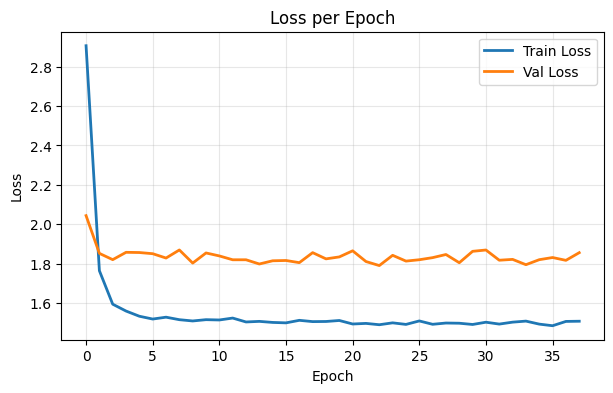

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Testing

In [27]:
# ============================================================
# LOAD BEST MODEL FOR EVALUATION
# ============================================================
# print("\nLoading best saved model for evaluation...")
# classifier = tf.keras.models.load_model(
#     "data/best_cnn_lstm_supcon_classifier.keras",
#     custom_objects={"loss": supervised_contrastive_loss(temperature=0.1)},
#  )
# print("Best model loaded successfully!")


In [28]:
# ============================================================
# STEP 8: EVALUATE ON TEST SET
# ============================================================
print("\nEvaluating on Test Set...")
y_pred_prob = classifier.predict(X_test_input, batch_size=32)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Decode labels
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

# Overall metrics
accuracy  = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted"
 )

print(f"\n{'='*50}")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"{'='*50}")


Evaluating on Test Set...
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

  Accuracy  : 68.65%
  Precision : 69.27%
  Recall    : 68.65%
  F1-Score  : 65.37%


In [29]:
# import shap

# np.random.seed(42)

# # ✅ Drastically reduced sample sizes
# SHAP_SAMPLE_SIZE = 20       # was 50 — biggest time saver
# SHAP_BACKGROUND_SIZE = 10   # was 25

# sample_size = min(SHAP_SAMPLE_SIZE, len(X_test_input))
# background_size = min(SHAP_BACKGROUND_SIZE, len(X_train_input))
# sample_idx = np.random.choice(len(X_test_input), size=sample_size, replace=False)
# background_idx = np.random.choice(len(X_train_input), size=background_size, replace=False)

# X_sample = X_test_input[sample_idx]
# X_background = X_train_input[background_idx]

# # ✅ batch_size limits how many samples are processed per forward pass
# explainer = shap.GradientExplainer(classifier, X_background)
# shap_values = explainer.shap_values(X_sample)  # was unbatched

# # ✅ Vectorized aggregation — avoids slow Python loops over samples/tokens
# shap_stack = np.stack([np.abs(sv) for sv in shap_values], axis=0)
# shap_abs = shap_stack.mean(axis=0)  # (n_samples, max_words, vec_dim)

# # ✅ Collapse embedding dim once upfront instead of inside the loop
# token_importance = shap_abs.mean(axis=-1)  # (n_samples, max_words)

# token_scores = {}
# for i, idx in enumerate(sample_idx):
#     tokens = X_test_tokens[idx]
#     scores = token_importance[i, :len(tokens)]   # ✅ slice once, no per-token mean()
#     for j, token in enumerate(tokens[:shap_abs.shape[1]]):
#         token_scores[token] = token_scores.get(token, 0.0) + float(scores[j])

# top_5 = sorted(token_scores.items(), key=lambda x: x[1], reverse=True)[:5]
# print("\nTop 5 tokens by mean |SHAP|:")
# for token, score in top_5:
#     print(f"  {token}: {score:.6f}")

### Visualisation

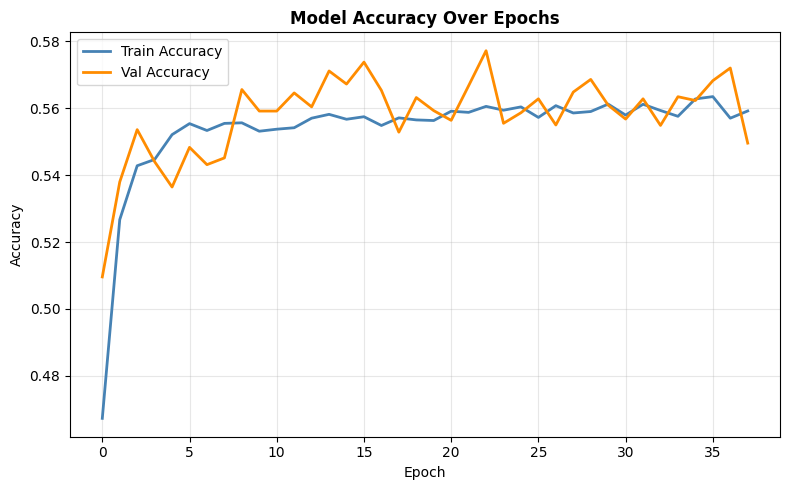

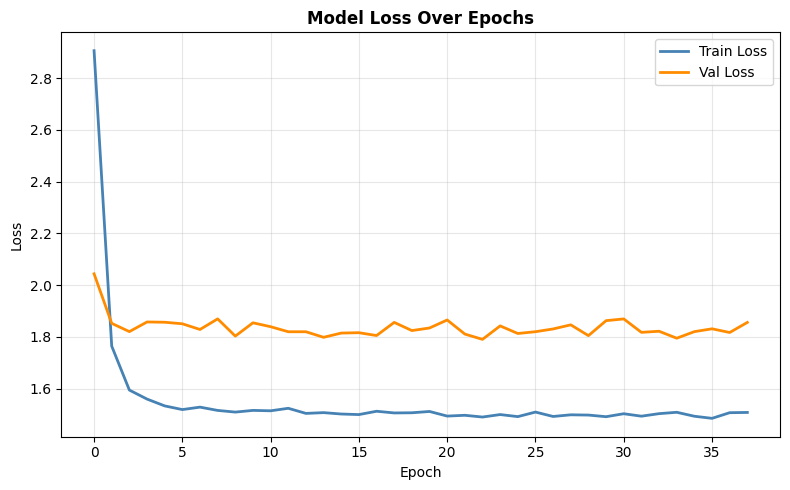

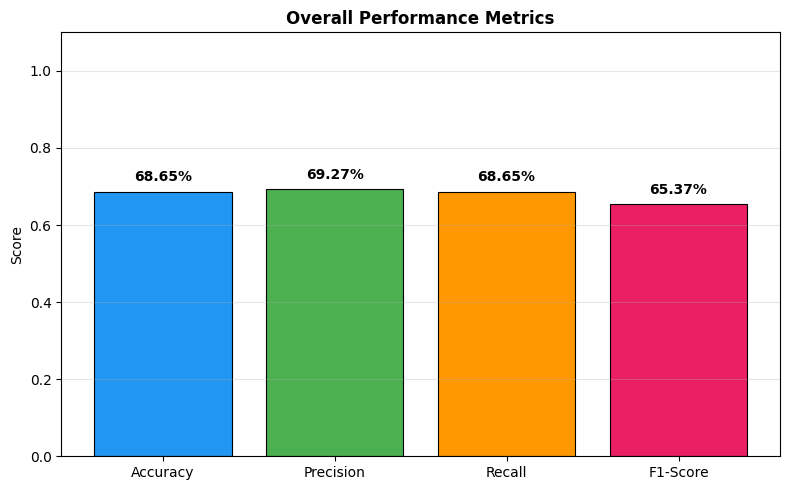

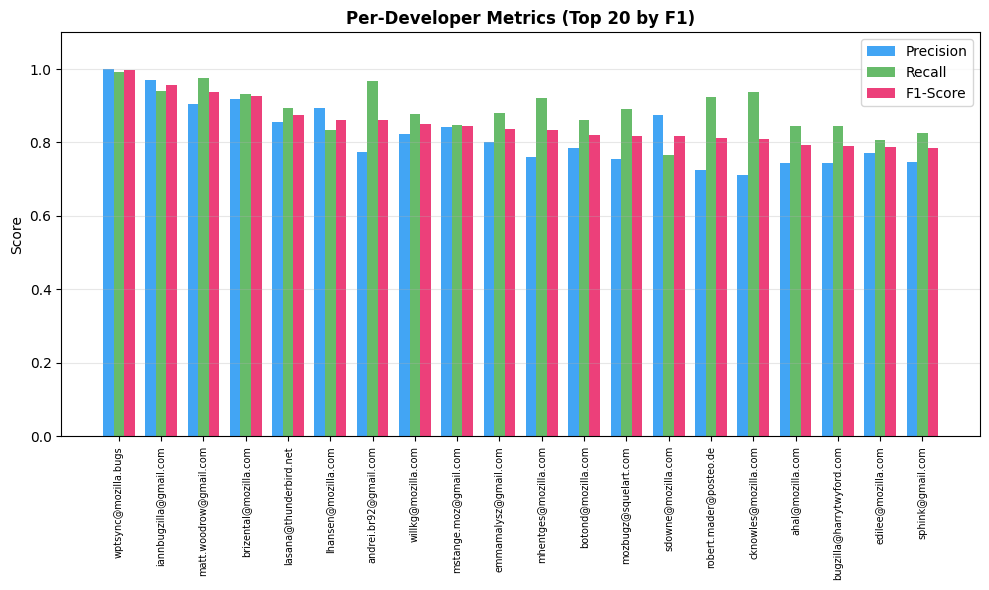

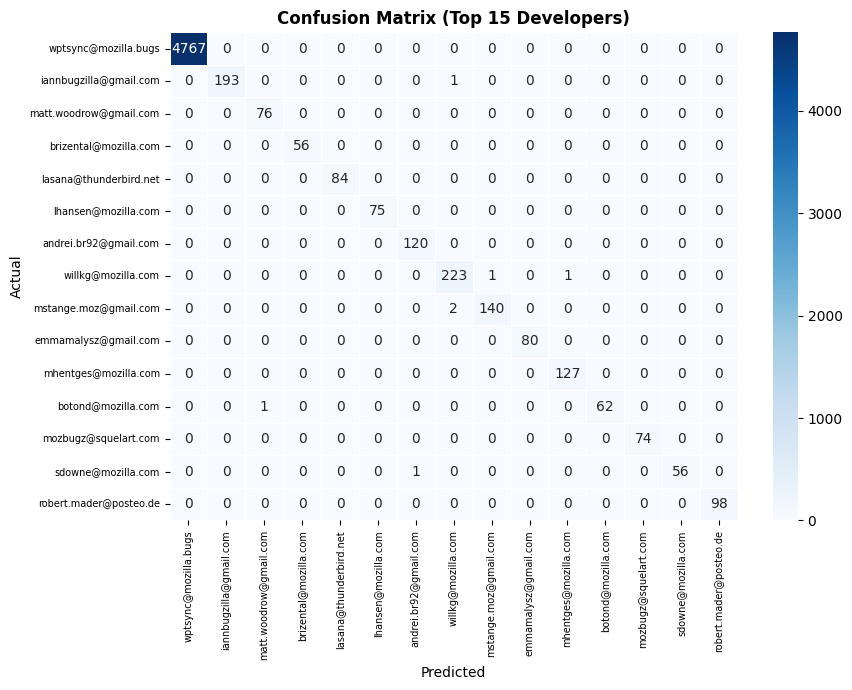

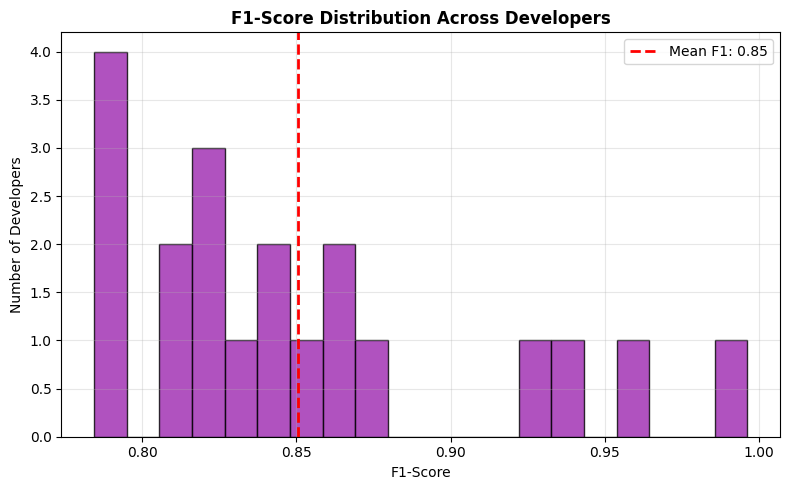


Charts saved as individual PNG files.


In [30]:
# ============================================================
# STEP 9: VISUALIZATION CHARTS
# ============================================================
# Chart 1: Training History - Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='darkorange', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('cnn_lstm_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Training History - Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='darkorange', linewidth=2)
plt.title('Model Loss Over Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('cnn_lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3: Overall Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=0.8)
plt.title('Overall Performance Metrics', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
# plt.savefig('cnn_lstm_overall_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4: Per-Class Precision Recall F1 (Top 20 developers)
report_dict = classification_report(
    y_test_labels, y_pred_labels, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
report_df = report_df[['precision', 'recall', 'f1-score']].astype(float)
report_df = report_df.sort_values('f1-score', ascending=False).head(20)

x = np.arange(len(report_df))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, report_df['precision'], width, label='Precision', color='#2196F3', alpha=0.85)
plt.bar(x, report_df['recall'], width, label='Recall', color='#4CAF50', alpha=0.85)
plt.bar(x + width, report_df['f1-score'], width, label='F1-Score', color='#E91E63', alpha=0.85)
plt.title('Per-Developer Metrics (Top 20 by F1)', fontweight='bold')
plt.xticks(x, report_df.index, rotation=90, fontsize=7)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('cnn_lstm_per_developer_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 5: Confusion Matrix (Top 15 developers)
top_15_devs = report_df.head(15).index.tolist()
mask_test = pd.Series(y_test_labels).isin(top_15_devs)
y_test_top15 = np.array(y_test_labels)[mask_test]
y_pred_top15 = np.array(y_pred_labels)[mask_test]

cm = confusion_matrix(y_test_top15, y_pred_top15, labels=top_15_devs)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=top_15_devs, yticklabels=top_15_devs,
    linewidths=0.5
 )
plt.title('Confusion Matrix (Top 15 Developers)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
# plt.savefig('cnn_lstm_confusion_matrix_top15.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 6: F1 Score Distribution
plt.figure(figsize=(8, 5))
plt.hist(report_df['f1-score'], bins=20, color='#9C27B0', edgecolor='black', alpha=0.8)
plt.axvline(
    report_df['f1-score'].mean(), color='red', linestyle='--', linewidth=2,
    label=f"Mean F1: {report_df['f1-score'].mean():.2f}"
)
plt.title('F1-Score Distribution Across Developers', fontweight='bold')
plt.xlabel('F1-Score')
plt.ylabel('Number of Developers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('cnn_lstm_f1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved as individual PNG files.")